In [7]:
# ── CELL 1: Imports & Load ────────────────────────────────────
import pandas as pd
import numpy as np
import requests
import time
import pickle
from pathlib import Path
from scipy.stats import mannwhitneyu

ROOT    = Path("..")
MATCH   = ROOT / "data" / "matched"
FIG     = ROOT / "data" / "figures"
EMAIL   = "you@email.com"
HEADERS = {"User-Agent": f"thesis-rq3/1.0 mailto:{EMAIL}"}
BASE    = "https://api.openalex.org"

# Load what we have
juniors  = pd.read_csv(MATCH / "junior_authors_all_conferences.csv")
pairs    = pd.read_csv(MATCH / "matched_pairs_clean.csv")
core     = pd.read_csv(MATCH / "conference_core_ranks.csv")

with open(MATCH / "award_source_map.pkl", "rb") as f:
    award_source_map = pickle.load(f)

# Unique conferences with source IDs
conf_sources = {
    conf: src
    for (conf, year), src in award_source_map.items()
    if src is not None
}
# Keep one source ID per conference (most recent non-null)
conf_source_final = {}
for (conf, year), src in sorted(award_source_map.items()):
    if src:
        conf_source_final[conf] = src

print(f"Conferences with source IDs: {len(conf_source_final)}")
print(list(conf_source_final.keys()))


Conferences with source IDs: 28
['AAAI', 'ACL', 'CHI', 'CIKM', 'CVPR', 'FOCS', 'FSE', 'ICCV', 'ICML', 'ICSE', 'IJCAI', 'INFOCOM', 'KDD', 'MOBICOM', 'NSDI', 'NeurIPS', 'OSDI', 'PLDI', 'PODS', 'S&P', 'SIGIR', 'SIGMOD', 'SODA', 'SOSP', 'STOC', 'UIST', 'VLDB', 'WWW']


In [ ]:
# ── CELL 2: Fetch award paper citations from OpenAlex ─────────
def fetch_work_citations(work_id, retries=3):
    url = f"{BASE}/works/{work_id}"
    params = {"select": "id,cited_by_count,publication_year"}
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=20)
            if r.status_code == 404:
                return None
            r.raise_for_status()
            return r.json()
        except Exception:
            time.sleep(2 ** attempt)
    return None

# Get unique award work IDs
award_works = juniors[["conference","award_year","work_id"]].drop_duplicates("work_id").reset_index(drop=True)

rows = []
for i, row in award_works.iterrows():
    data = fetch_work_citations(row["work_id"])
    if data:
        rows.append({
            "conference":      row["conference"],
            "award_year":      row["award_year"],
            "work_id":         row["work_id"],
            "cited_by_count":  data.get("cited_by_count", 0),
            "type": "award"
        })
    if i % 50 == 0:
        print(f"  {i}/{len(award_works)} fetched")
    time.sleep(0.3)

award_citations = pd.DataFrame(rows)
award_citations.to_csv(MATCH / "award_paper_citations.csv", index=False)
print(f"\nAward papers fetched: {len(award_citations)}")
print(award_citations["cited_by_count"].describe().round(1))


  0/470 fetched
  50/470 fetched
  250/470 fetched
  300/470 fetched
  400/470 fetched
  500/470 fetched
  550/470 fetched
  600/470 fetched

Award papers fetched: 470
count      470.0
mean       308.2
std       1453.0
min          0.0
25%         45.0
50%        102.5
75%        203.5
max      28027.0
Name: cited_by_count, dtype: float64


In [9]:
# ── CELL 3: Fetch regular paper sample per conference ─────────
def fetch_conf_papers(source_id, n=50, retries=3):
    """Fetch a random sample of papers from a conference source."""
    url = f"{BASE}/works"
    params = {
        "filter":   f"primary_location.source.id:{source_id},type:article",
        "select":   "id,cited_by_count,publication_year",
        "per-page": "100",
        "sort":     "display_name",   # alphabetical = no citation bias
    }
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=20)
            r.raise_for_status()
            results = r.json().get("results", [])
            import random
            random.seed(42)
            return random.sample(results, min(n, len(results)))
        except Exception:
            time.sleep(2 ** attempt)
    return []

rows = []
for conf, src_id in conf_source_final.items():
    papers = fetch_conf_papers(src_id, n=50)
    for p in papers:
        rows.append({
            "conference":     conf,
            "work_id":        p["id"].split("/")[-1],
            "cited_by_count": p.get("cited_by_count", 0),
            "pub_year":       p.get("publication_year"),
            "type":           "regular"
        })
    print(f"  {conf}: {len(papers)} papers fetched")
    time.sleep(1)

regular_citations = pd.DataFrame(rows)
regular_citations.to_csv(MATCH / "regular_paper_citations.csv", index=False)
print(f"\nRegular papers fetched: {len(regular_citations)}")


  AAAI: 50 papers fetched
  ACL: 50 papers fetched
  CHI: 50 papers fetched
  CIKM: 50 papers fetched
  CVPR: 50 papers fetched
  FOCS: 50 papers fetched
  FSE: 50 papers fetched
  ICCV: 50 papers fetched
  ICML: 50 papers fetched
  ICSE: 50 papers fetched
  IJCAI: 50 papers fetched
  INFOCOM: 50 papers fetched
  KDD: 50 papers fetched
  MOBICOM: 50 papers fetched
  NSDI: 50 papers fetched
  NeurIPS: 50 papers fetched
  OSDI: 50 papers fetched
  PLDI: 50 papers fetched
  PODS: 50 papers fetched
  S&P: 50 papers fetched
  SIGIR: 50 papers fetched
  SIGMOD: 50 papers fetched
  SODA: 50 papers fetched
  SOSP: 50 papers fetched
  STOC: 50 papers fetched
  UIST: 50 papers fetched
  VLDB: 50 papers fetched
  WWW: 50 papers fetched

Regular papers fetched: 1400


In [10]:
# ── CELL 4: Per-conference quality metrics ────────────────────
results = []

for conf in sorted(award_citations["conference"].unique()):
    a = award_citations[award_citations["conference"] == conf]["cited_by_count"].dropna()
    b = regular_citations[regular_citations["conference"] == conf]["cited_by_count"].dropna()

    if len(a) < 3 or len(b) < 3:
        continue

    stat, p = mannwhitneyu(a, b, alternative="greater")
    ratio = a.median() / b.median() if b.median() > 0 else np.nan

    results.append({
        "conference":       conf,
        "award_median":     round(a.median(), 1),
        "regular_median":   round(b.median(), 1),
        "citation_ratio":   round(ratio, 2),
        "n_award":          len(a),
        "n_regular":        len(b),
        "p":                round(p, 4),
        "significant":      p < 0.05,
    })

quality_df = pd.DataFrame(results).sort_values("citation_ratio", ascending=False)

# Merge CORE rank
core_map = (pairs[["conference","core_rank"]].drop_duplicates()
            .set_index("conference")["core_rank"])
quality_df["core_rank"] = quality_df["conference"].map(core_map)

quality_df.to_csv(FIG / "16_conference_quality.csv", index=False)
print(quality_df.to_string(index=False))


conference  award_median  regular_median  citation_ratio  n_award  n_regular      p  significant core_rank
     SIGIR         226.0             1.0          226.00        8         50 0.0002         True        A*
       CHI         108.0             1.0          108.00       91         50 0.0000         True        A*
   MOBICOM         162.0             2.0           81.00        7         50 0.0003         True        A*
      NSDI          87.0             2.0           43.50        5         50 0.0020         True  Unranked
      CVPR         443.0            18.5           23.95       10         50 0.0001         True        A*
       ACL         217.5            19.0           11.45       14         50 0.0002         True  Unranked
       KDD         223.0            20.0           11.15       11         50 0.0000         True  Unranked
      SOSP         166.0            18.5            8.97       15         50 0.0002         True        A*
      ICML         162.0            1

C:\Users\sla99\AppData\Local\Temp\ipykernel_71164\2127401132.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="black",   edgecolor="black", label="p < 0.05 (significant)"),
C:\Users\sla99\AppData\Local\Temp\ipykernel_71164\2127401132.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#aaaaaa", edgecolor="black", label="p ≥ 0.05 (not significant)"),


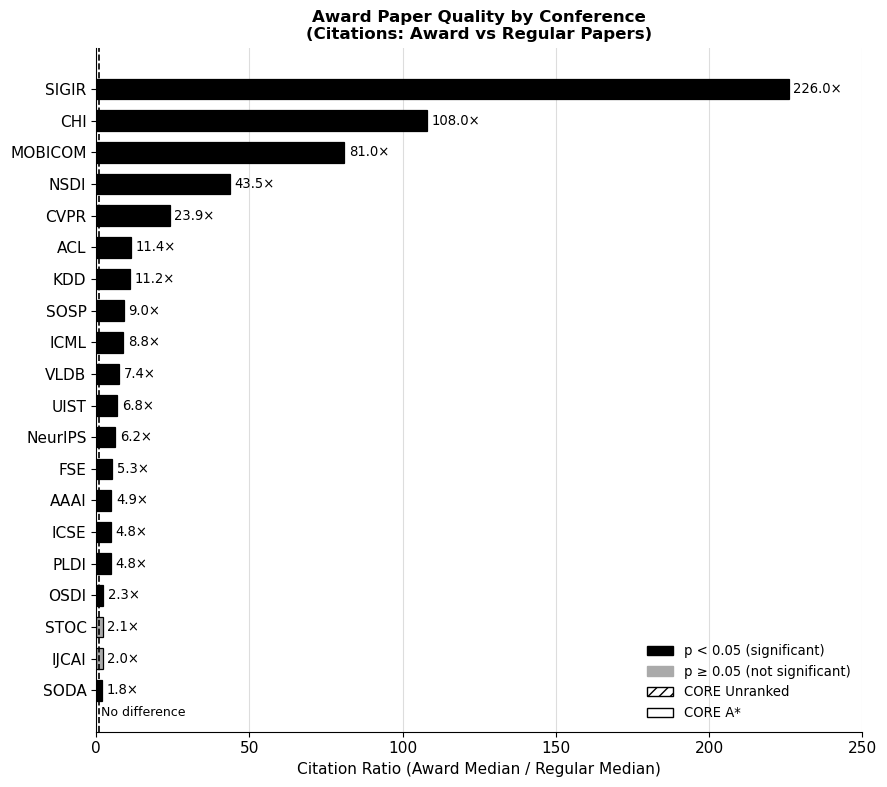

Saved.


In [12]:
# ── CELL 5: Visualise conference quality ─────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})

known_sorted = quality_df.dropna(subset=["citation_ratio"]).sort_values("citation_ratio")

confs   = known_sorted["conference"].tolist()
ratios  = known_sorted["citation_ratio"].tolist()
sig     = known_sorted["significant"].tolist()
ranks   = known_sorted["core_rank"].tolist()

colors  = ["black" if s else "#aaaaaa" for s in sig]
hatches = ["" if r == "A*" else "///" for r in ranks]   # ← only this line

legend_patches = [
    mpatches.Patch(color="black",   edgecolor="black", label="p < 0.05 (significant)"),
    mpatches.Patch(color="#aaaaaa", edgecolor="black", label="p ≥ 0.05 (not significant)"),
    mpatches.Patch(facecolor="white", edgecolor="black", hatch="///", label="CORE Unranked"),
    mpatches.Patch(facecolor="white", edgecolor="black", label="CORE A*"),
]

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(confs, ratios, color=colors, edgecolor="black",
               linewidth=0.9, height=0.65)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
for bar, v in zip(bars, ratios):
    ax.text(v + 1.5, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}×", va="center", fontsize=9.5)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2)
ax.text(1.5, -0.9, "No difference", fontsize=9, va="bottom")
ax.set_xlabel("Citation Ratio (Award Median / Regular Median)")
ax.set_title("Award Paper Quality by Conference\n(Citations: Award vs Regular Papers)",
             fontweight="bold", fontsize=12)
ax.legend(handles=legend_patches, frameon=False, fontsize=9.5, loc="lower right")
ax.xaxis.grid(True, color="#dddddd", zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 250)

plt.tight_layout()
plt.savefig(FIG / "16_citation_ratio_by_conf.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved.")
